## Train model

In [15]:
# Cell 1 — Imports & helper functions
import pandas as pd
import numpy as np
from pathlib import Path

DATA_HYDRO = Path("./data_thuydien/du_lieu_thuy_dien_processed_final2.csv")
DATA_WEATHER = Path("./data_thuydien/HoaBinh.csv")

def smart_read_csv(path):
    """Try common encodings to read CSV robustly."""
    for enc in ["utf-8", "utf-8-sig", "cp1258", "latin-1", "utf-16"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last_err = e
    raise last_err

def find_col(df, candidates):
    cols = list(df.columns)
    lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand in lower:
            return lower[cand]
    # fuzzy contains
    for c in cols:
        lc = c.lower()
        if any(cand in lc for cand in candidates):
            return c
    return None

def to_datetime_col(df, colname, dayfirst=True):
    df[colname] = pd.to_datetime(df[colname], errors="coerce", dayfirst=dayfirst, utc=False)
    # Drop rows that failed to parse
    before = len(df)
    df = df.dropna(subset=[colname]).copy()
    after = len(df)
    if after < before:
        print(f"[INFO] Dropped {before-after} rows due to invalid datetimes in '{colname}'.")
    # Normalize to hourly alignment to improve join rate
    df[colname] = df[colname].dt.floor("H")
    return df

print("✓ Helpers ready.")


✓ Helpers ready.


In [16]:
# Cell 2 — Load raw data & inspect columns
hydro_raw = smart_read_csv(DATA_HYDRO)
weather_raw = smart_read_csv(DATA_WEATHER)

print("[Hydro] shape:", hydro_raw.shape)
print(hydro_raw.columns.tolist()[:50])

print("\n[Weather] shape:", weather_raw.shape)
print(weather_raw.columns.tolist()[:50])


[Hydro] shape: (33264, 22)
['thoi_diem', 'muc_nuoc_thuong_luu_m', 'luu_luong_den_ho_m3_s_capped', 'tong_luong_xa_m3_s', 'tong_luong_xa_qua_dap_tran_m3_s', 'tong_luong_xa_qua_nha_may_m3_s', 'phase_pre_lu_som', 'phase_lu_som', 'phase_lu_chinh_vu', 'phase_tai_tich', 'pct_change', 'anom_iqr_units', 'out_pct', 'is_event_month', 'luu_luong_den_ho_m3_s_capped_month_median', 'luu_luong_den_ho_m3_s_capped_pct_in_month', 'max_xa_dap_tran', 'max_xa_nha_may', 'dap_tran_norm', 'nha_may_norm', 'month', 'mua_vu']

[Weather] shape: (33264, 10)
['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'precipitation (mm)', 'wind_speed_10m (km/h)', 'cloud_cover (%)', 'surface_pressure (hPa)', 'et0_fao_evapotranspiration (mm)', 'rain (mm)', 'snowfall (cm)']


In [17]:
# Cell 3 (làm lại) — Chuẩn hoá time (M/D/YYYY HH:MM), sort theo thoi_diem (datetime), và merge không mất dòng
import pandas as pd
from pathlib import Path

HYDRO_CSV   = Path("./data_thuydien/du_lieu_thuy_dien_processed_final2.csv")
WEATHER_CSV = Path("./data_thuydien/HoaBinh.csv")
OUT_MERGED  = Path("./data_thuydien/merged_hoa_binh_keyjoin.csv")

TIME_COL_HYDRO   = "thoi_diem"
TIME_COL_WEATHER = "time"

WEATHER_KEEP = ['temperature_2m (°C)', 'relative_humidity_2m (%)', 'precipitation (mm)', 'cloud_cover (%)']
WEATHER_RENAME = {
    'temperature_2m (°C)': 'temp_c',
    'relative_humidity_2m (%)': 'rh_pct',
    'precipitation (mm)': 'precip_mm',
    'cloud_cover (%)': 'cloud_pct'
}

DROP_COLS = ['month', 'tong_luong_xa_m3_s', 'tong_luong_xa_qua_dap_tran_m3_s',
             'tong_luong_xa_qua_nha_may_m3_s', 'max_xa_dap_tran', 'max_xa_nha_may']

def smart_read_csv(path):
    for enc in ["utf-8", "utf-8-sig", "cp1258", "latin-1", "utf-16"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            pass
    return pd.read_csv(path)

def parse_best_datetime(series):
    s1 = pd.to_datetime(series, errors="coerce", dayfirst=False)
    s2 = pd.to_datetime(series, errors="coerce", dayfirst=True)
    if s1.notna().sum() >= s2.notna().sum():
        return s1
    return s2

def to_key_string(dt_series):
    dt = pd.to_datetime(dt_series, errors="coerce").dt.floor("H")
    return (dt.dt.month.astype("Int64").astype(str) + "/" +
            dt.dt.day.astype("Int64").astype(str) + "/" +
            dt.dt.year.astype("Int64").astype(str) + " " +
            dt.dt.hour.astype("Int64").astype(str).str.zfill(2) + ":" +
            dt.dt.minute.astype("Int64").astype(str).str.zfill(2))

# 1) Read
hydro_raw   = smart_read_csv(HYDRO_CSV)
weather_raw = smart_read_csv(WEATHER_CSV)

# 2) Weather: chọn cột, parse & tạo key
weather = weather_raw[[TIME_COL_WEATHER] + WEATHER_KEEP].copy()
weather["__dt_w"] = parse_best_datetime(weather[TIME_COL_WEATHER]).dt.floor("H")
weather = weather.dropna(subset=["__dt_w"]).copy()
weather["time_key"] = to_key_string(weather["__dt_w"])
weather = weather.rename(columns=WEATHER_RENAME)

# 3) Hydro: drop cột thừa, parse & tạo key
hydro = hydro_raw.drop(columns=[c for c in DROP_COLS if c in hydro_raw.columns], errors="ignore").copy()
assert TIME_COL_HYDRO in hydro.columns, f"Thiếu cột {TIME_COL_HYDRO} trong thủy điện"
hydro["__dt_h"] = parse_best_datetime(hydro[TIME_COL_HYDRO]).dt.floor("H")
hydro = hydro.dropna(subset=["__dt_h"]).copy()
hydro["time_key"] = to_key_string(hydro["__dt_h"])

# 4) Xử lý trùng time_key trước khi merge (giữ bản ghi đầu tiên mỗi time_key)
hydro = hydro.sort_values("__dt_h").drop_duplicates(subset=["time_key"], keep="first")
weather = weather.sort_values("__dt_w").drop_duplicates(subset=["time_key"], keep="first")

# 5) Merge và tạo lại thoi_diem chuẩn datetime
merged = pd.merge(
    hydro.drop(columns=["__dt_h"]), 
    weather.drop(columns=["__dt_w"]),
    on="time_key", how="inner", suffixes=("", "_w")
)

# Dự phòng: nếu cột 'thoi_diem' là chuỗi, tạo lại từ time_key để đảm bảo chuẩn
merged["thoi_diem"] = pd.to_datetime(merged["thoi_diem"], errors="coerce")
mask_na = merged["thoi_diem"].isna()
if mask_na.any():
    merged.loc[mask_na, "thoi_diem"] = pd.to_datetime(merged.loc[mask_na, "time_key"], format="%m/%d/%Y %H:%M", errors="coerce")

# 6) Sort theo thoi_diem và reset index
merged = merged.sort_values("thoi_diem").reset_index(drop=True)

# 7) Kiểm tra độ bao phủ thời gian
print("Merged shape:", merged.shape)
print("Time range:", merged["thoi_diem"].min(), "->", merged["thoi_diem"].max())
print("Head times:", merged["thoi_diem"].head().tolist())
print("Tail times:", merged["thoi_diem"].tail().tolist())

# 8) Lưu
merged.to_csv(OUT_MERGED, index=False)
print("Saved merged sorted to:", OUT_MERGED)


Merged shape: (33264, 22)
Time range: 2022-01-01 00:00:00 -> 2025-10-17 23:00:00
Head times: [Timestamp('2022-01-01 00:00:00'), Timestamp('2022-01-01 01:00:00'), Timestamp('2022-01-01 02:00:00'), Timestamp('2022-01-01 03:00:00'), Timestamp('2022-01-01 04:00:00')]
Tail times: [Timestamp('2025-10-17 19:00:00'), Timestamp('2025-10-17 20:00:00'), Timestamp('2025-10-17 21:00:00'), Timestamp('2025-10-17 22:00:00'), Timestamp('2025-10-17 23:00:00')]
Saved merged sorted to: data_thuydien/merged_hoa_binh_keyjoin.csv


In [18]:
import pandas as pd
from pathlib import Path

MERGED_PATH = Path('./data_thuydien/merged_hoa_binh_keyjoin.csv')
TARGET_COL = 'muc_nuoc_thuong_luu_m'
FEATURE_WEATHER = ['temp_c','rh_pct','precip_mm','cloud_pct']

df = pd.read_csv(MERGED_PATH)
df['thoi_diem'] = pd.to_datetime(df['thoi_diem'], errors='coerce', dayfirst=False)
df = df.sort_values('thoi_diem').reset_index(drop=True)

n = len(df)
split_idx = int(n*0.8)
df_train = df.iloc[:split_idx].reset_index(drop=True)
df_test  = df.iloc[split_idx:].reset_index(drop=True)

print('Train:', df_train['thoi_diem'].min(), '->', df_train['thoi_diem'].max(), len(df_train))
print('Test :', df_test['thoi_diem'].min(),  '->', df_test['thoi_diem'].max(),  len(df_test))


Train: 2022-01-01 00:00:00 -> 2025-01-13 18:00:00 26611
Test : 2025-01-13 19:00:00 -> 2025-10-17 23:00:00 6653


In [19]:
# Cell 5 — Sequences 28 ngày: [muc_nuoc, luu_luong, temp_c, rh_pct, precip_mm, cloud_pct]
import numpy as np

LOOKBACK_DAYS = 28
STRIDE = 1  # tăng lên 2 hoặc 3 nếu thiếu RAM/GPU

FEATURE_WEATHER = ['temp_c','rh_pct','precip_mm','cloud_pct']
TARGET_COL = 'muc_nuoc_thuong_luu_m'
INFLOW_CANDIDATES = ['luu_luong_den_ho_m3_s_capped', 'luu_luong_den_ho_m3_s']

assert 'df' in globals() and 'split_idx' in globals(), "Chạy Cell 4 trước."
INFLOW_COL = next((c for c in INFLOW_CANDIDATES if c in df.columns), None)
assert INFLOW_COL is not None, "Thiếu cột lưu lượng đến hồ."

# Suy ra bước thời gian theo giờ -> số bước mỗi ngày
delta_hours = df['thoi_diem'].diff().dt.total_seconds().dropna()/3600.0
median_step_h = float(delta_hours.median()) if len(delta_hours)>0 else 1.0
steps_per_day = int(round(24.0/median_step_h)) if median_step_h>0 else 24
RAW_L = LOOKBACK_DAYS*steps_per_day
print(f"Median step (h)= {median_step_h:.2f} | steps/day= {steps_per_day} | RAW_L={RAW_L} | STRIDE={STRIDE}")

# Chuẩn bị dữ liệu nguồn
need_cols = ['thoi_diem', TARGET_COL, INFLOW_COL] + FEATURE_WEATHER
sub = df[need_cols].dropna().reset_index(drop=True)

arr_level = sub[TARGET_COL].values.astype('float32')
arr_inflw = sub[INFLOW_COL].values.astype('float32')
arr_w = sub[FEATURE_WEATHER].values.astype('float32')  # (N, 4)
y_all = sub[TARGET_COL].values.astype('float32')

# Build windows
X_seq, X_w, y, t_idx = [], [], [], []
for t in range(RAW_L, len(sub)):
    sl = slice(t-RAW_L, t)
    # downsample theo STRIDE
    lvl_win = arr_level[sl][::STRIDE]
    inf_win = arr_inflw[sl][::STRIDE]
    w_win   = arr_w[sl][::STRIDE]              # (L_eff, 4)

    # ghép thành 6 kênh theo trục feature: (L_eff, 6)
    seq_6 = np.column_stack([lvl_win, inf_win, w_win])
    X_seq.append(seq_6.astype('float32'))

    # thời tiết "tại thời điểm dự báo" KHÔNG dùng nữa theo IO mới → để placeholder (có thể bỏ)
    X_w.append(np.zeros(4, dtype='float32'))   # giữ nhánh thời tiết cho tương thích kiến trúc; hoặc bỏ hoàn toàn ở Cell 7

    y.append(y_all[t].astype('float32'))
    t_idx.append(sub.index[t])

X_seq = np.stack(X_seq, axis=0)   # (N, L_eff, 6)
X_w   = np.stack(X_w,   axis=0)   # (N, 4) – sẽ không dùng, có thể xóa ở Cell 7 nếu muốn
y     = np.array(y, dtype='float32')
t_idx = np.array(t_idx)

# Split theo split_idx
train_mask = t_idx < split_idx
test_mask  = t_idx >= split_idx

Xseq_tr, Xw_tr, y_tr = X_seq[train_mask], X_w[train_mask], y[train_mask]
Xseq_te, Xw_te, y_te = X_seq[test_mask],  X_w[test_mask],  y[test_mask]

SEQ_FEAT_DIM = Xseq_tr.shape[2]
L_eff = Xseq_tr.shape[1]
print('Train/Test:',
      Xseq_tr.shape, Xseq_te.shape, y_tr.shape, y_te.shape,
      '| FEAT_DIM=', SEQ_FEAT_DIM, '| L_eff=', L_eff)


Median step (h)= 1.00 | steps/day= 24 | RAW_L=672 | STRIDE=1
Train/Test: (25939, 672, 6) (6653, 672, 6) (25939,) (6653,) | FEAT_DIM= 6 | L_eff= 672


In [20]:
# Cell 6 — Scaling (đa kênh) + save scalers to .pkl
import numpy as np
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import joblib

Ntr, L_eff, F = Xseq_tr.shape
Nte = Xseq_te.shape[0]

seq_scaler = StandardScaler()
y_scaler   = StandardScaler()

# Flatten theo (N, L*F) rồi reshape lại
Xseq_tr_2d = Xseq_tr.reshape(Ntr, L_eff*F)
Xseq_te_2d = Xseq_te.reshape(Nte, L_eff*F)

Xseq_tr_s = seq_scaler.fit_transform(Xseq_tr_2d).astype('float32').reshape(Ntr, L_eff, F)
Xseq_te_s = seq_scaler.transform(Xseq_te_2d).astype('float32').reshape(Nte, L_eff, F)

y_tr_s = y_scaler.fit_transform(y_tr.reshape(-1,1)).astype('float32').ravel()
y_te_s = y_scaler.transform(y_te.reshape(-1,1)).astype('float32').ravel()

print("Scaled:",
      "Xseq_tr_s", Xseq_tr_s.shape, "| Xseq_te_s", Xseq_te_s.shape,
      "| y_tr_s", y_tr_s.shape, "| y_te_s", y_te_s.shape)

# ---- Save scalers ----
SCALER_DIR = Path("./checkpoint/cnn_lstm")
TAG = f"28d_stride{STRIDE}_6ch"   # để phân biệt các cấu hình
seq_path = SCALER_DIR / f"seq_scaler_{TAG}.pkl"
y_path   = SCALER_DIR / f"y_scaler_{TAG}.pkl"

joblib.dump(seq_scaler, seq_path)
joblib.dump(y_scaler, y_path)
print("Saved scalers to:")
print("  ", seq_path)
print("  ", y_path)

Scaled: Xseq_tr_s (25939, 672, 6) | Xseq_te_s (6653, 672, 6) | y_tr_s (25939,) | y_te_s (6653,)
Saved scalers to:
   checkpoint/cnn_lstm/seq_scaler_28d_stride1_6ch.pkl
   checkpoint/cnn_lstm/y_scaler_28d_stride1_6ch.pkl


In [21]:
# Cell 7 — Model: 1 nhánh sequence (6 kênh) theo IO mới
import torch
import torch.nn as nn

class CNNLSTM(nn.Module):
    def __init__(self, seq_feat_dim,
                 conv_filters=16, lstm_hidden=64, dense_hidden=32, dropout=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(seq_feat_dim, conv_filters, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(conv_filters, conv_filters, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.lstm = nn.LSTM(input_size=conv_filters, hidden_size=lstm_hidden, batch_first=True)
        self.norm = nn.LayerNorm(lstm_hidden)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(lstm_hidden, dense_hidden), nn.ReLU(),
            nn.Linear(dense_hidden, 1)
        )

    def forward(self, x_seq):
        # x_seq: (N, L, F) -> (N, F, L)
        x = x_seq.transpose(1, 2)
        x = self.conv(x)          # (N, F', L')
        x = x.transpose(1, 2)     # (N, L', F')
        out, _ = self.lstm(x)     # (N, L', H)
        h = out[:, -1, :]         # (N, H)
        h = self.norm(h)
        h = self.dropout(h)
        return self.head(h).squeeze(1)

import torch.backends.cudnn as cudnn
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cudnn.benchmark = True

model = CNNLSTM(seq_feat_dim=Xseq_tr_s.shape[2],
                conv_filters=16, lstm_hidden=64, dense_hidden=32, dropout=0.1).to(DEVICE)
print(model)

# Nếu bạn muốn giữ NHÁNH THỜI TIẾT TĨNH như cũ:
# - Thêm w_in, fc_w và concat trước head (xem phiên bản trước).
# - Khi đó nhớ scale & truyền Xw_tr_s/Xw_te_s trong Cell 8–9.

CNNLSTM(
  (conv): Sequential(
    (0): Conv1d(6, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(16, 64, batch_first=True)
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [22]:
# Cell 8 — Train (AMP + early stopping, 1 nhánh)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path

BATCH_SIZE   = 256      # giảm nếu OOM
EPOCHS       = 25
LR           = 1e-3
WEIGHT_DECAY = 1e-4
CLIP_NORM    = 1.0
PATIENCE     = 6
MODEL_PATH   = "./checkpoint/cnn_lstm/cnn_lstm_model_seq6_28d.pth"

class HydroDataset(Dataset):
    def __init__(self, Xseq, y):
        self.Xseq = torch.tensor(Xseq, dtype=torch.float32)
        self.y    = torch.tensor(y,    dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.Xseq[idx], self.y[idx]

# Chronological split: 10% cuối train làm val
n_tr = len(Xseq_tr_s)
val_size = max(1, int(0.1*n_tr))
train_size = n_tr - val_size

train_ds = HydroDataset(Xseq_tr_s[:train_size], y_tr_s[:train_size])
val_ds   = HydroDataset(Xseq_tr_s[train_size:],  y_tr_s[train_size:])

pin = (DEVICE.type == 'cuda')
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin, num_workers=0)

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3, verbose=True)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=='cuda'))

best_val = float('inf'); best_state=None; pat=PATIENCE

for epoch in range(1, EPOCHS+1):
    # Train
    model.train()
    tr_losses=[]; tr_mae=[]
    for xb_seq, yb in train_loader:
        xb_seq = xb_seq.to(DEVICE, non_blocking=True)
        yb     = yb.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
            yhat = model(xb_seq)
            loss = criterion(yhat, yb)
        scaler.scale(loss).backward()
        nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
        scaler.step(optimizer); scaler.update()

        tr_losses.append(loss.detach().float().item())
        tr_mae.append(torch.mean(torch.abs(yhat - yb)).detach().float().item())

    # Val
    model.eval()
    vl_losses=[]; vl_mae=[]
    with torch.no_grad(), torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
        for xb_seq, yb in val_loader:
            xb_seq = xb_seq.to(DEVICE, non_blocking=True)
            yb     = yb.to(DEVICE, non_blocking=True)
            yhat = model(xb_seq)
            loss = criterion(yhat, yb)
            vl_losses.append(loss.detach().float().item())
            vl_mae.append(torch.mean(torch.abs(yhat - yb)).detach().float().item())

    tr_l = float(np.mean(tr_losses)); vl_l = float(np.mean(vl_losses))
    tr_m = float(np.mean(tr_mae));    vl_m = float(np.mean(vl_mae))
    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={tr_l:.6f} val_loss={vl_l:.6f} | train_mae={tr_m:.6f} val_mae={vl_m:.6f}")
    scheduler.step(vl_l)

    if vl_l < best_val - 1e-8:
        best_val = vl_l; pat = PATIENCE
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        pat -= 1
        if pat <= 0:
            print("Early stopping.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

torch.save(model.state_dict(), MODEL_PATH)
print("Saved model to", MODEL_PATH)

Epoch 01/25 | train_loss=1.002640 val_loss=0.546670 | train_mae=0.793539 val_mae=0.734971
Epoch 02/25 | train_loss=0.317856 val_loss=0.370454 | train_mae=0.442001 val_mae=0.606464
Epoch 03/25 | train_loss=0.176872 val_loss=0.390851 | train_mae=0.320308 val_mae=0.623589
Epoch 04/25 | train_loss=0.093604 val_loss=0.239591 | train_mae=0.232946 val_mae=0.479942
Epoch 05/25 | train_loss=0.086420 val_loss=0.078471 | train_mae=0.227510 val_mae=0.276787
Epoch 06/25 | train_loss=0.057049 val_loss=0.048356 | train_mae=0.185797 val_mae=0.210604
Epoch 07/25 | train_loss=0.087015 val_loss=0.190896 | train_mae=0.204954 val_mae=0.434925
Epoch 08/25 | train_loss=0.094931 val_loss=0.302890 | train_mae=0.224317 val_mae=0.548132
Epoch 09/25 | train_loss=0.031198 val_loss=0.238831 | train_mae=0.139706 val_mae=0.484891
Epoch 10/25 | train_loss=0.089040 val_loss=0.015569 | train_mae=0.189158 val_mae=0.119647
Epoch 11/25 | train_loss=0.058526 val_loss=0.338486 | train_mae=0.154576 val_mae=0.580228
Epoch 12/2

In [23]:
# Cell 9 — Evaluate & export predictions
import numpy as np
import pandas as pd
import torch
from pathlib import Path

model.eval()
preds = []
BS = 512
with torch.no_grad(), torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
    for i in range(0, len(Xseq_te_s), BS):
        xb_seq = torch.tensor(Xseq_te_s[i:i+BS], dtype=torch.float32, device=DEVICE)
        yhat   = model(xb_seq).detach().cpu().numpy().ravel()
        preds.append(yhat)
yhat_s = np.concatenate(preds, axis=0)

# inverse scale về đơn vị m
y_pred = y_scaler.inverse_transform(yhat_s.reshape(-1,1)).ravel()
y_true = y_te

# metrics
mae  = float(np.mean(np.abs(y_true - y_pred)))
rmse = float(np.sqrt(np.mean((y_true - y_pred)**2)))
print(f"TEST — MAE={mae:.4f} | RMSE={rmse:.4f} (m)")

# lưu kết quả
times = sub.loc[t_idx[test_mask], 'thoi_diem'].reset_index(drop=True)
pred_df = pd.DataFrame({'thoi_diem': times, 'y_true': y_true, 'y_pred': y_pred})
pred_df['abs_err'] = np.abs(pred_df['y_true'] - pred_df['y_pred'])
pred_path  = Path('./checkpoint/cnn_lstm/predictions_cnn_lstm_seq6_28d.csv')
toperr_path= Path('./checkpoint/cnn_lstm/predictions_top_abs_err_seq6_28d.csv')
pred_df.to_csv(pred_path, index=False)
pred_df.sort_values('abs_err', ascending=False).head(100).to_csv(toperr_path, index=False)
print("Saved:", pred_path)
print("Saved:", toperr_path)
print(pred_df.head(5))


TEST — MAE=2.0138 | RMSE=3.6427 (m)
Saved: checkpoint/cnn_lstm/predictions_cnn_lstm_seq6_28d.csv
Saved: checkpoint/cnn_lstm/predictions_top_abs_err_seq6_28d.csv
            thoi_diem      y_true    y_pred   abs_err
0 2025-01-13 19:00:00  115.169998  115.5625  0.392502
1 2025-01-13 20:00:00  115.169998  115.5625  0.392502
2 2025-01-13 21:00:00  115.180000  115.5625  0.382500
3 2025-01-13 22:00:00  115.180000  115.6250  0.445000
4 2025-01-13 23:00:00  115.180000  115.6250  0.445000


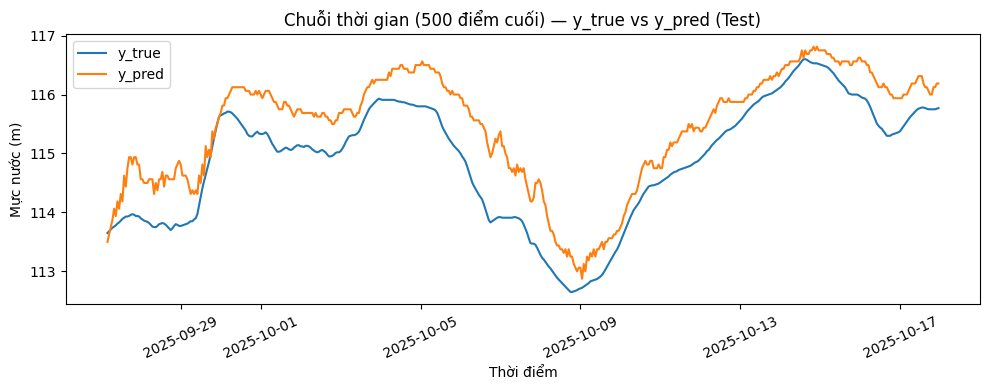

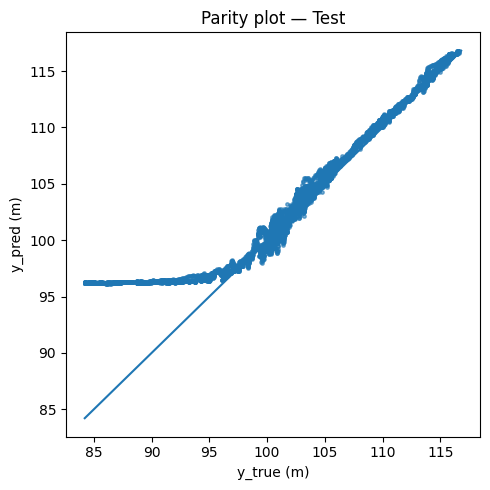

In [24]:
# Cell 9_plot — Plot test predictions (time-series + parity)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Giả định bạn vừa chạy Cell 9 và có pred_df, y_true, y_pred, times trong scope.
# Nếu không, đọc từ file CSV:
if 'pred_df' not in globals():
    _pred_path = "./checkpoint/cnn_lstm/predictions_cnn_lstm_seq6_28d.csv"
    pred_df = pd.read_csv(_pred_path, parse_dates=["thoi_diem"])

# 1) Time-series (lấy 500 điểm cuối cho dễ nhìn)
k = 500
slice_idx = slice(max(0, len(pred_df)-k), len(pred_df))
plt.figure(figsize=(10,4))
plt.plot(pred_df["thoi_diem"].values[slice_idx], pred_df["y_true"].values[slice_idx], label="y_true")
plt.plot(pred_df["thoi_diem"].values[slice_idx], pred_df["y_pred"].values[slice_idx], label="y_pred")
plt.title("Chuỗi thời gian (500 điểm cuối) — y_true vs y_pred (Test)")
plt.xlabel("Thời điểm")
plt.ylabel("Mực nước (m)")
plt.xticks(rotation=25)
plt.legend()
plt.tight_layout()
plt.show()

# 2) Parity plot: y_true vs y_pred
plt.figure(figsize=(5,5))
plt.scatter(pred_df["y_true"].values, pred_df["y_pred"].values, s=6, alpha=0.6)
mn = float(np.min([pred_df["y_true"].min(), pred_df["y_pred"].min()]))
mx = float(np.max([pred_df["y_true"].max(), pred_df["y_pred"].max()]))
plt.plot([mn, mx], [mn, mx])  # đường y=x
plt.title("Parity plot — Test")
plt.xlabel("y_true (m)")
plt.ylabel("y_pred (m)")
plt.tight_layout()
plt.show()


## Demo

In [26]:
# ==== Suy luận 24/10/2025 02:00 với loader scaler "robust" ====
import os, pickle, gzip, bz2, lzma
import numpy as np
import pandas as pd
import torch, torch.nn as nn
from pathlib import Path
from collections import Counter

# --------- Đường dẫn theo bạn ---------
ENRICHED_CSV   = Path("./data_thuydien/data_thuydien_enriched.csv")
MODEL_PATH     = Path("./checkpoint/cnn_lstm/cnn_lstm_model_seq6_28d.pth")
SEQ_SCALER_PKL = Path("./checkpoint/cnn_lstm/seq_scaler_28d_stride1_6ch.pkl")
Y_SCALER_PKL   = Path("./checkpoint/cnn_lstm/y_scaler_28d_stride1_6ch.pkl")

TARGET_TIME = "25/10/2025 07:00"  # dd/MM/yyyy HH:mm

TARGET_COL  = "muc_nuoc_thuong_luu_m"
INFLOW_COL  = "luu_luong_den_ho_m3_s"
W_COLS      = ["temperature_2m (°C)", "relative_humidity_2m (%)", "precipitation (mm)", "cloud_cover (%)"]
ALL_REQ     = [TARGET_COL, INFLOW_COL] + W_COLS

from sklearn.preprocessing import StandardScaler

def robust_load_scaler(path: Path):
    """Thử nhiều cách để load scaler. Trả về (scaler, msg)."""
    if not path.exists():
        return None, f"Không thấy file: {path}"
    try:
        import joblib
    except Exception:
        joblib = None

    # Đọc bytes 1 lần
    data = path.read_bytes()

    # 1) joblib.load trực tiếp
    if joblib is not None:
        try:
            return joblib.load(path), f"Loaded by joblib.load({path})"
        except Exception as e:
            msg1 = f"joblib.load fail: {repr(e)}"
    else:
        msg1 = "joblib not available"

    # 2) pickle.loads
    try:
        return pickle.loads(data), f"Loaded by pickle.loads({path})"
    except Exception as e:
        msg2 = f"pickle.loads fail: {repr(e)}"

    # 3) gzip -> pickle
    try:
        return pickle.loads(gzip.decompress(data)), f"Loaded by gzip+pickle ({path})"
    except Exception as e:
        msg3 = f"gzip+pickle fail: {repr(e)}"

    # 4) bz2 -> pickle
    try:
        return pickle.loads(bz2.decompress(data)), f"Loaded by bz2+pickle ({path})"
    except Exception as e:
        msg4 = f"bz2+pickle fail: {repr(e)}"

    # 5) lzma -> pickle
    try:
        return pickle.loads(lzma.decompress(data)), f"Loaded by lzma+pickle ({path})"
    except Exception as e:
        msg5 = f"lzma+pickle fail: {repr(e)}"

    return None, " | ".join([msg1, msg2, msg3, msg4, msg5])

# --------- Model 6 kênh (giống lúc train) ---------
class CNNLSTM(nn.Module):
    def __init__(self, seq_feat_dim=6, conv_filters=16, lstm_hidden=64, dense_hidden=32, dropout=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(seq_feat_dim, conv_filters, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(conv_filters, conv_filters, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.lstm = nn.LSTM(input_size=conv_filters, hidden_size=lstm_hidden, batch_first=True)
        self.norm = nn.LayerNorm(lstm_hidden)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(nn.Linear(lstm_hidden, dense_hidden), nn.ReLU(), nn.Linear(dense_hidden, 1))
    def forward(self, x_seq):
        x = x_seq.transpose(1, 2)  # (N,F,L)
        x = self.conv(x)           # (N,C,L')
        x = x.transpose(1, 2)      # (N,L',C)
        out,_ = self.lstm(x)       # (N,L',H)
        h = out[:, -1, :]          # (N,H)
        h = self.norm(h)
        h = self.dropout(h)
        return self.head(h).squeeze(1)

# --------- Kiểm tra files ---------
print("[CHECK]", ENRICHED_CSV, "->", ENRICHED_CSV.exists())
print("[CHECK]", MODEL_PATH, "->", MODEL_PATH.exists())
print("[CHECK]", SEQ_SCALER_PKL, "->", SEQ_SCALER_PKL.exists())
print("[CHECK]", Y_SCALER_PKL, "->", Y_SCALER_PKL.exists())

# --------- Load model ---------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNLSTM().to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

# --------- Robust load scalers (hoặc fallback) ---------
seq_scaler, msg_seq = robust_load_scaler(SEQ_SCALER_PKL)
print("[LOAD seq_scaler]", msg_seq)
y_scaler, msg_y = robust_load_scaler(Y_SCALER_PKL)
print("[LOAD y_scaler]", msg_y)

# --------- Đọc enriched & chuẩn hoá thời gian ---------
df_en = pd.read_csv(ENRICHED_CSV)
time_col = next((c for c in ["thoi_diem","time","datetime","timestamp"] if c in df_en.columns), None)
assert time_col is not None, "Thiếu cột thời gian trong enriched CSV."
t1 = pd.to_datetime(df_en[time_col], errors="coerce", dayfirst=True)
t2 = pd.to_datetime(df_en[time_col], errors="coerce", dayfirst=False)
t = t1 if t1.notna().sum() >= t2.notna().sum() else t2
df_en = df_en.assign(__dt=t).dropna(subset=["__dt"]).sort_values("__dt").reset_index(drop=True)

for col in ALL_REQ:
    assert col in df_en.columns, f"Thiếu cột '{col}' trong enriched CSV."
    df_en[col] = pd.to_numeric(df_en[col], errors="coerce")

# --------- Suy ra độ dài EXPECT_L & bước thời gian ----------
target_dt = pd.to_datetime(TARGET_TIME, dayfirst=True)
assert pd.notna(target_dt), f"Không parse được TARGET_TIME: {TARGET_TIME}"
total_minutes = 28*24*60

def infer_expect_L_from_scaler(scaler):
    n_features_in = getattr(scaler, "n_features_in_", None)
    if n_features_in and n_features_in % 6 == 0:
        return n_features_in // 6
    return None

EXPECT_L = infer_expect_L_from_scaler(seq_scaler) if seq_scaler is not None else None

if EXPECT_L is None:
    # Thử suy ra bước thời gian từ enriched
    dmins = np.diff(df_en["__dt"].view("i8")) / 60_000_000_000  # ns->min
    dmins = dmins[dmins > 0]
    if len(dmins) > 0:
        step_minutes = int(Counter(dmins.astype(int)).most_common(1)[0][0])
        EXPECT_L = int(round(total_minutes / step_minutes))
        print(f"[WARN] Không dùng được scaler chuỗi; suy ra EXPECT_L={EXPECT_L} từ enriched (step ~{step_minutes} phút).")
    else:
        EXPECT_L = 28*24  # fallback hourly
        step_minutes = 60
        print(f"[WARN] enriched không đủ để suy ra bước; dùng mặc định EXPECT_L={EXPECT_L} (hourly).")
else:
    step_minutes = int(round(total_minutes / EXPECT_L))

freq_str = f"{step_minutes}min"
print(f"[INFO] EXPECT_L={EXPECT_L}, step_minutes={step_minutes}")

# --------- Tạo lưới đều cho 28 ngày trước target ---------
start_dt = target_dt - pd.Timedelta(days=28)
grid = pd.date_range(start=start_dt,
                     end=target_dt - pd.Timedelta(minutes=step_minutes),
                     freq=freq_str, inclusive="both")
if len(grid) != EXPECT_L:
    # Điều chỉnh end để đúng chiều dài (trường hợp làm tròn)
    grid = pd.date_range(start=start_dt, periods=EXPECT_L, freq=freq_str)

# --------- Merge vào grid và fill ---------
base = df_en[["__dt"] + ALL_REQ].sort_values("__dt")
joined = pd.merge_asof(pd.DataFrame({"__dt": grid}), base, on="__dt", direction="backward")
joined[ALL_REQ] = joined[ALL_REQ].ffill().interpolate(limit_direction="both")
if joined[ALL_REQ].isna().any().any():
    bad = joined.columns[joined.isna().any()].tolist()
    raise ValueError(f"Còn NaN sau fill/interpolate ở các cột: {bad}. Bổ sung enriched CSV.")

lvl = joined[TARGET_COL].values.astype("float32")
inf = joined[INFLOW_COL].values.astype("float32")
w4  = joined[W_COLS].values.astype("float32")
seq6 = np.column_stack([lvl, inf, w4])  # (L,6)
assert seq6.shape == (EXPECT_L, 6), f"seq6 shape {seq6.shape} != ({EXPECT_L},6)"

# --------- Scale chuỗi: dùng scaler nếu có, ngược lại fit tạm trên cửa sổ (demo) ---------
x2d = seq6.reshape(1, EXPECT_L*6).astype("float32")
if seq_scaler is None:
    print("[WARN] seq_scaler không load được -> fit tạm trên cửa sổ (demo).")
    seq_scaler = StandardScaler().fit(x2d)  # chỉ để demo
x2d_s = seq_scaler.transform(x2d).astype("float32")
x_seq_s = x2d_s.reshape(1, EXPECT_L, 6)

# --------- Inference ---------
with torch.no_grad():
    xb = torch.tensor(x_seq_s, dtype=torch.float32, device=DEVICE)
    yhat_s = model(xb).cpu().numpy().ravel()[0]

# --------- Inverse scale target ---------
if y_scaler is None:
    print("[WARN] y_scaler không load được -> không inverse được tuyệt đối; in ra giá trị chuẩn hoá.")
    y_pred = float(yhat_s)  # giá trị trên thang chuẩn hoá
else:
    y_pred = float(y_scaler.inverse_transform([[yhat_s]]).ravel()[0])

print("==== DỰ BÁO MỰC NƯỚC THƯỢNG LƯU ====")
print(f"Thời điểm dự báo: {target_dt} | EXPECT_L={EXPECT_L} bước (mỗi {step_minutes} phút)")
print(f"Kết quả dự báo (m): {y_pred:.4f}")

[CHECK] data_thuydien/data_thuydien_enriched.csv -> True
[CHECK] checkpoint/cnn_lstm/cnn_lstm_model_seq6_28d.pth -> True
[CHECK] checkpoint/cnn_lstm/seq_scaler_28d_stride1_6ch.pkl -> True
[CHECK] checkpoint/cnn_lstm/y_scaler_28d_stride1_6ch.pkl -> True
[LOAD seq_scaler] Loaded by joblib.load(checkpoint/cnn_lstm/seq_scaler_28d_stride1_6ch.pkl)
[LOAD y_scaler] Loaded by joblib.load(checkpoint/cnn_lstm/y_scaler_28d_stride1_6ch.pkl)
[INFO] EXPECT_L=672, step_minutes=60
==== DỰ BÁO MỰC NƯỚC THƯỢNG LƯU ====
Thời điểm dự báo: 2025-10-25 07:00:00 | EXPECT_L=672 bước (mỗi 60 phút)
Kết quả dự báo (m): 116.0331
